In [4]:
# Cell 1: Setup + Load Comments
import os, re, time, random
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

SEED = 42
def seed_everything(s=42):
    random.seed(s); os.environ['PYTHONHASHSEED']=str(s)
    np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(SEED); os.makedirs("outputs", exist_ok=True)

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
text_col = 'Review Text' if 'Review Text' in df.columns else df.columns[4]
rating_col = 'Rating' if 'Rating' in df.columns else df.columns[5]
df = df[[text_col, rating_col]].dropna()
df['label'] = (df[rating_col] >= 4).astype(int)

def clean_text(t):
    t = str(t).lower(); t = re.sub(r'[^a-zA-Z\s]', '', t); return t.strip()

df['clean_text'] = df[text_col].apply(clean_text)

words = " ".join(df['clean_text']).split()
wc = Counter(words)
vocab = {w: i+2 for i,(w,c) in enumerate(wc.most_common(5000))}
vocab['<PAD>'] = 0; vocab['<UNK>'] = 1

MAX_LEN = 60
def encode(t):
    toks = [vocab.get(w, 1) for w in t.split()][:MAX_LEN]
    return toks + [0]*(MAX_LEN - len(toks))

X = np.array([encode(t) for t in df['clean_text']])
y = df['label'].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.15, random_state=SEED, stratify=y_tr)
print(f"Vocab: {len(vocab)} | Train/Val/Test: {len(X_tr)}/{len(X_val)}/{len(X_te)}")

train_loader = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.long),
                                         torch.tensor(y_tr, dtype=torch.long)),
                          batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.long),
                                       torch.tensor(y_val, dtype=torch.long)),
                        batch_size=64, shuffle=False)
X_te_t = torch.tensor(X_te, dtype=torch.long)

Vocab: 5002 | Train/Val/Test: 15395/2717/4529


In [5]:
# Cell 2: Baseline TextCNN (1 kernel size)
class BaselineTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv = nn.Conv1d(embed_dim, 64, kernel_size=3)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        e = self.embedding(x).transpose(1,2)
        h = torch.relu(self.conv(e))
        p = self.pool(h).squeeze(-1)
        return self.fc(p)

def train_cls(model, tr_loader, val_loader, epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device); crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    hist = {'train_loss':[], 'val_acc':[]}
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tl, n = 0., 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); out = model(xb)
            loss = crit(out, yb); loss.backward(); opt.step()
            tl += loss.item()*len(yb); n += len(yb)
        model.eval(); corr, vn = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                corr += (model(xb).argmax(1)==yb).sum().item(); vn += len(yb)
        hist['train_loss'].append(tl/n); hist['val_acc'].append(corr/vn)
        print(f"Epoch {ep+1:02d}/{epochs} | loss={tl/n:.4f} | val_acc={corr/vn:.4f}")
    return hist, time.time()-t0

seed_everything(SEED)
baseline = BaselineTextCNN(len(vocab))
hist_base, t_base = train_cls(baseline, train_loader, val_loader, epochs=10)

Epoch 01/10 | loss=0.4521 | val_acc=0.8134
Epoch 02/10 | loss=0.3294 | val_acc=0.8403
Epoch 03/10 | loss=0.2695 | val_acc=0.8454
Epoch 04/10 | loss=0.2242 | val_acc=0.8502
Epoch 05/10 | loss=0.1817 | val_acc=0.8535
Epoch 06/10 | loss=0.1451 | val_acc=0.8531
Epoch 07/10 | loss=0.1110 | val_acc=0.8528
Epoch 08/10 | loss=0.0832 | val_acc=0.8572
Epoch 09/10 | loss=0.0600 | val_acc=0.8568
Epoch 10/10 | loss=0.0416 | val_acc=0.8554


In [6]:
# Cell 3: Improved TextCNN (multi-kernel 2/3/4 + BN + Dropout)
class ImprovedTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_classes=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 64, 2)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(embed_dim, 64, 3)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(embed_dim, 64, 4)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(64*3, num_classes)
    def forward(self, x):
        e = self.embedding(x).transpose(1,2)
        p1 = torch.max(torch.relu(self.bn1(self.conv1(e))), dim=2)[0]
        p2 = torch.max(torch.relu(self.bn2(self.conv2(e))), dim=2)[0]
        p3 = torch.max(torch.relu(self.bn3(self.conv3(e))), dim=2)[0]
        out = torch.cat([p1,p2,p3], dim=1)
        return self.fc(self.dropout(out))

seed_everything(SEED)
improved = ImprovedTextCNN(len(vocab))
hist_imp, t_imp = train_cls(improved, train_loader, val_loader, epochs=10)

Epoch 01/10 | loss=0.5423 | val_acc=0.8163
Epoch 02/10 | loss=0.4128 | val_acc=0.8355
Epoch 03/10 | loss=0.3734 | val_acc=0.8524
Epoch 04/10 | loss=0.3466 | val_acc=0.8520
Epoch 05/10 | loss=0.3253 | val_acc=0.8403
Epoch 06/10 | loss=0.3075 | val_acc=0.8543
Epoch 07/10 | loss=0.2918 | val_acc=0.8561
Epoch 08/10 | loss=0.2708 | val_acc=0.8664
Epoch 09/10 | loss=0.2551 | val_acc=0.8682
Epoch 10/10 | loss=0.2522 | val_acc=0.8653


In [7]:
# Cell 4: TensorFlow/Keras TextCNN
import tensorflow as tf
from tensorflow.keras import layers, models
tf.random.set_seed(SEED)

def build_tf_text(vocab_size, embed_dim=64, maxlen=60):
    m = models.Sequential([
        layers.Input(shape=(maxlen,)),
        layers.Embedding(vocab_size, embed_dim, mask_zero=False),
        layers.Conv1D(64, 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Conv1D(64, 3, activation='relu'),
        layers.BatchNormalization(),
        layers.Conv1D(64, 4, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dropout(0.4),
        layers.Dense(2, activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

tf_text = build_tf_text(len(vocab)); tf_text.summary()
t0 = time.time()
tf_text.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=10, batch_size=64, verbose=0)
t_tf = time.time() - t0
tf_pred_prob = tf_text.predict(X_te, verbose=0)
tf_pred = tf_pred_prob.argmax(1)
print(f"TensorFlow TextCNN — {t_tf:.2f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 60, 64)              │         320,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 59, 64)              │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 59, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 57, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 57, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 54, 64)              │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 357,826 (1.36 MB)

 Trainable params: 357,570 (1.36 MB)

 Non-trainable params: 256 (1.00 KB)

TensorFlow TextCNN — 99.18s


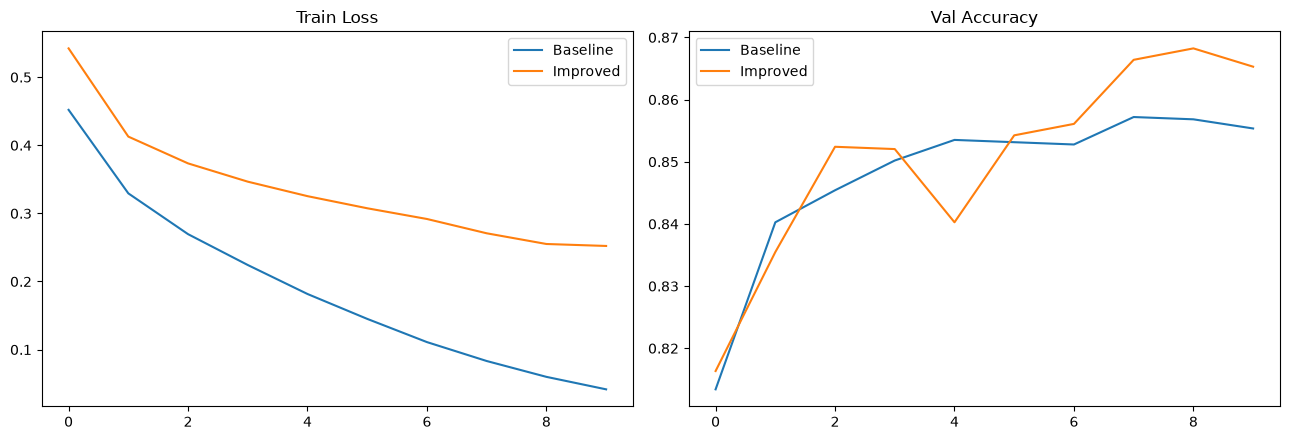

In [8]:
# Cell 5: Training curves
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
axes[0].plot(hist_base['train_loss'], label='Baseline')
axes[0].plot(hist_imp['train_loss'], label='Improved')
axes[0].set_title("Train Loss"); axes[0].legend()
axes[1].plot(hist_base['val_acc'], label='Baseline')
axes[1].plot(hist_imp['val_acc'], label='Improved')
axes[1].set_title("Val Accuracy"); axes[1].legend()
plt.tight_layout(); plt.savefig("outputs/comments_curves.png", dpi=200); plt.show()


--- PyTorch Improved ---
                    precision    recall  f1-score   support

Tiêu cực/Trung lập       0.77      0.59      0.67      1039
          Tích cực       0.89      0.95      0.92      3490

          accuracy                           0.87      4529
         macro avg       0.83      0.77      0.79      4529
      weighted avg       0.86      0.87      0.86      4529


--- TensorFlow ---
                    precision    recall  f1-score   support

Tiêu cực/Trung lập       0.71      0.57      0.63      1039
          Tích cực       0.88      0.93      0.90      3490

          accuracy                           0.85      4529
         macro avg       0.79      0.75      0.77      4529
      weighted avg       0.84      0.85      0.84      4529



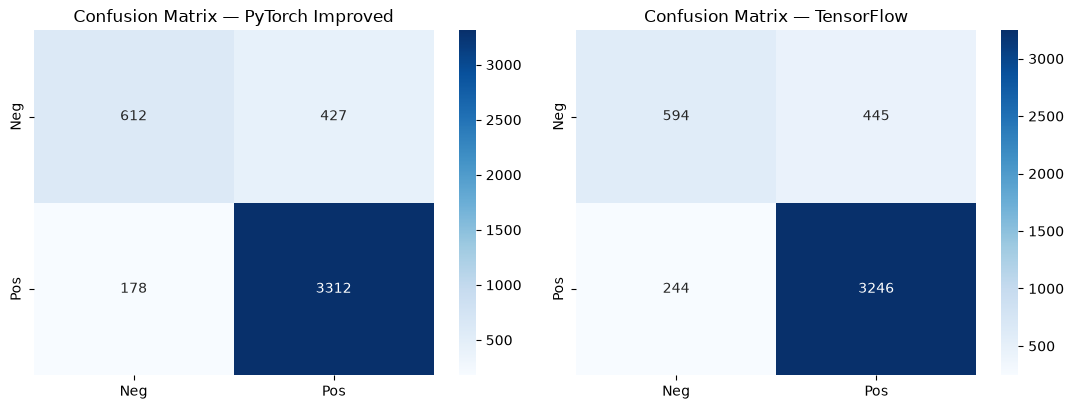

In [9]:
# Cell 6: Evaluate PyTorch & TensorFlow
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
improved.eval()
with torch.no_grad():
    pt_prob = torch.softmax(improved(X_te_t.to(device)), 1)[:,1].cpu().numpy()
pt_pred = (pt_prob >= 0.5).astype(int)

def report(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print(classification_report(y_true, y_pred,
          target_names=['Tiêu cực/Trung lập','Tích cực']))

report("PyTorch Improved", y_te, pt_pred)
report("TensorFlow", y_te, tf_pred)

fig, axes = plt.subplots(1,2,figsize=(11,4.2))
for ax, cm, t in zip(axes, [confusion_matrix(y_te, pt_pred),
                            confusion_matrix(y_te, tf_pred)],
                     ['PyTorch Improved','TensorFlow']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    ax.set_title(f"Confusion Matrix — {t}")
plt.tight_layout(); plt.savefig("outputs/comments_confusion.png", dpi=200); plt.show()

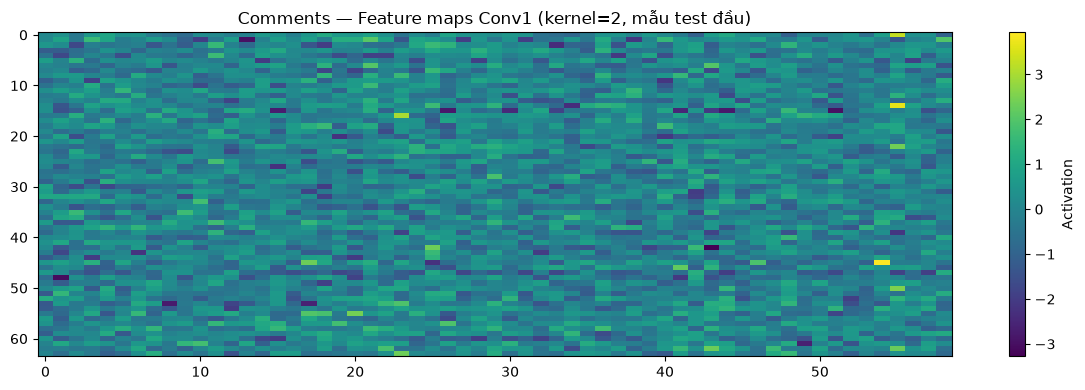

In [10]:
# Cell 7: Feature maps của conv1 (kernel=2)
improved.eval()
with torch.no_grad():
    sample_emb = improved.embedding(X_te_t[0:1].to(device)).transpose(1,2)
    fm = improved.conv1(sample_emb).squeeze(0).cpu().numpy()
plt.figure(figsize=(12,4))
plt.imshow(fm, aspect='auto', cmap='viridis')
plt.colorbar(label='Activation')
plt.title("Comments — Feature maps Conv1 (kernel=2, mẫu test đầu)")
plt.tight_layout(); plt.savefig("outputs/comments_feature_maps.png", dpi=200); plt.show()

In [12]:
# Cell 8: High-confidence errors
def high_conf_errors(y_true, y_prob, top_k=15, thresh=0.9, texts=None):
    y_pred = (y_prob >= 0.5).astype(int)
    wrong = y_pred != y_true
    conf = np.where(y_pred==1, y_prob, 1-y_prob)
    sel = wrong & (conf >= thresh)
    idx = np.where(sel)[0]
    idx = idx[np.argsort(-conf[idx])][:top_k]
    df_out = pd.DataFrame({
        'idx': idx, 'true': y_true[idx], 'pred': y_pred[idx],
        'confidence': conf[idx]
    })
    if texts is not None:
        df_out['text'] = [texts[i] for i in idx]
    return df_out

test_texts = df.iloc[len(df) - len(y_te):][text_col].values if False else None
err = high_conf_errors(y_te, pt_prob, top_k=15, thresh=0.9)
print("HIGH-CONFIDENCE ERRORS (PyTorch):")
print(err.to_string(index=False))
err.to_csv("outputs/comments_high_conf_errors.csv", index=False)

# Test câu thực tế
sample_reviews = [
    "This dress is absolutely gorgeous and fits perfectly! Love it.",
    "Very bad quality, fabric is too thin and size is completely wrong."
]
improved.eval()
for r in sample_reviews:
    seq = torch.tensor([encode(clean_text(r))], dtype=torch.long).to(device)
    with torch.no_grad():
        p = torch.softmax(improved(seq),1)[0,1].item()
    print(f"'{r}'\n  -> {'TÍCH CỰC' if p>=0.5 else 'TIÊU CỰC'} (p={p:.4f})")

HIGH-CONFIDENCE ERRORS (PyTorch):
 idx  true  pred  confidence
 733     0     1    0.999657
3710     0     1    0.995665
2768     0     1    0.995268
1770     0     1    0.994732
1728     0     1    0.994669
1161     0     1    0.993517
2364     0     1    0.992031
 863     1     0    0.990664
1526     0     1    0.990458
3063     0     1    0.988928
4110     0     1    0.987727
4404     0     1    0.986914
3056     0     1    0.986765
 780     0     1    0.986661
2713     0     1    0.986356
'This dress is absolutely gorgeous and fits perfectly! Love it.'
  -> TÍCH CỰC (p=0.9999)
'Very bad quality, fabric is too thin and size is completely wrong.'
  -> TIÊU CỰC (p=0.1125)


In [15]:
# Cell 9: Summary
baseline.eval()
with torch.no_grad():
    base_prob = torch.softmax(baseline(X_te_t.to(device)), 1)[:, 1].cpu().numpy()
base_pred = (base_prob >= 0.5).astype(int)

summary = pd.DataFrame([
    {'Framework':'PyTorch Baseline','Accuracy':accuracy_score(y_te, base_pred),
     'F1':f1_score(y_te, base_pred),'Time':t_base},
    {'Framework':'PyTorch Improved','Accuracy':accuracy_score(y_te, pt_pred),
     'F1':f1_score(y_te, pt_pred),'Time':t_imp},
    {'Framework':'TensorFlow','Accuracy':accuracy_score(y_te, tf_pred),
     'F1':f1_score(y_te, tf_pred),'Time':t_tf},
])
print(summary.to_string(index=False))
summary.to_csv("outputs/comments_framework.csv", index=False)

       Framework  Accuracy       F1      Time
PyTorch Baseline  0.855376 0.908070 20.633106
PyTorch Improved  0.866416 0.916309 47.868339
      TensorFlow  0.847869 0.904052 99.182830
